In [1]:
# ── mock external service for notebook context ─────────────────────────────
import random

class ExternalAPI:
    def fetch_rate(self, currency: str) -> float:
        # simulate network latency / IO
        print(f"Fetching {currency} from API...")
        return round(random.uniform(0.8, 1.5), 4)

external_api = ExternalAPI()

# ── imports ────────────────────────────────────────────────────────────────
from functools import lru_cache, cache

# ── lru_cache: bounded, LRU eviction ──────────────────────────────────────
@lru_cache(maxsize=512)
def get_exchange_rate(currency: str) -> float:
    return external_api.fetch_rate(currency)      # expensive

# ── functools.cache: unbounded (no LRU overhead — ~40% faster) ────────────
@cache
def fib(n: int) -> int:
    if n < 2:
        return n
    return fib(n - 1) + fib(n - 2)               # O(n) with cache, O(2^n) without

# ── inspect cache stats ────────────────────────────────────────────────────
get_exchange_rate("USD")
get_exchange_rate("EUR")
get_exchange_rate("USD")                          # cache hit

info = get_exchange_rate.cache_info()
# CacheInfo(hits=1, misses=2, maxsize=512, currsize=2)
print(f"Hit rate: {info.hits / (info.hits + info.misses):.0%}")

# ── clear cache manually ───────────────────────────────────────────────────
get_exchange_rate.cache_clear()

Fetching USD from API...
Fetching EUR from API...
Hit rate: 33%


In [3]:
type(info)

functools.CacheInfo

In [4]:
# what @lru_cache(maxsize=512) actually does under the hood — simplified
def lru_cache_manual(maxsize=512):
    _store = {}          # the hidden dict
    _order = []          # tracks access order for LRU eviction

    def decorator(func):
        def wrapper(*args):
            if args in _store:
                # cache hit — move to end (most recent)
                _order.remove(args)
                _order.append(args)
                return _store[args]
            
            # cache miss — call real function
            result = func(*args)
            _store[args] = result
            _order.append(args)

            if len(_store) > maxsize:
                oldest = _order.pop(0)   # LRU eviction
                del _store[oldest]

            return result
        return wrapper
    return decorator

In [5]:
# ── mock external service ──────────────────────────────────────────────────
import random

class ExternalAPI:
    def fetch_rate(self, currency: str) -> float:
        print(f"  [API CALL] Fetching {currency}...")
        return round(random.uniform(0.8, 1.5), 4)

external_api = ExternalAPI()

from functools import lru_cache, cache

@lru_cache(maxsize=512)
def get_exchange_rate(currency: str) -> float:
    return external_api.fetch_rate(currency)

@cache
def fib(n: int) -> int:
    if n < 2:
        return n
    return fib(n - 1) + fib(n - 2)


# ── 1. what attributes does the wrapper expose? ────────────────────────────
print(dir(get_exchange_rate))
# [..., 'cache_clear', 'cache_info', 'cache_parameters', '__wrapped__', ...]


# ── 2. cache_info() — the main stats object ───────────────────────────────
get_exchange_rate("USD")
get_exchange_rate("EUR")
get_exchange_rate("USD")    # hit

info = get_exchange_rate.cache_info()
print(info)
# CacheInfo(hits=1, misses=2, maxsize=512, currsize=2)

print(type(info))           # <class 'functools._CacheInfo'>

# access individual fields
print(f"hits      : {info.hits}")       # 1
print(f"misses    : {info.misses}")     # 2
print(f"maxsize   : {info.maxsize}")    # 512
print(f"currsize  : {info.currsize}")   # 2  (entries currently stored)
print(f"hit rate  : {info.hits / (info.hits + info.misses):.0%}")  # 33%


# ── 3. cache_parameters() — how it was configured ─────────────────────────
print(get_exchange_rate.cache_parameters())
# {'maxsize': 512, 'typed': False}

# @cache has no maxsize — its parameters show:
fib(10)
print(fib.cache_parameters())
# {'maxsize': None, 'typed': False}


# ── 4. __wrapped__ — the original unwrapped function ──────────────────────
print(get_exchange_rate.__wrapped__)
# <function get_exchange_rate at 0x...>

# call original function directly, bypassing cache completely
raw = get_exchange_rate.__wrapped__("USD")
print(f"raw call (no cache): {raw}")   # always hits API


# ── 5. cache_clear() — wipe everything ────────────────────────────────────
get_exchange_rate.cache_clear()
info_after = get_exchange_rate.cache_info()
print(info_after)
# CacheInfo(hits=0, misses=0, maxsize=512, currsize=0)  ← reset to zero


# ── 6. @cache on fib — same API, just maxsize=None ────────────────────────
fib(30)
fib_info = fib.cache_info()
print(fib_info)
# CacheInfo(hits=28, misses=31, maxsize=None, currsize=31)
#                                ^^^^^^^^^^^
#                    None = unbounded, will never evict

['__annotations__', '__call__', '__class__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__get__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__name__', '__ne__', '__new__', '__qualname__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__type_params__', '__wrapped__', 'cache_clear', 'cache_info', 'cache_parameters']
  [API CALL] Fetching USD...
  [API CALL] Fetching EUR...
CacheInfo(hits=1, misses=2, maxsize=512, currsize=2)
<class 'functools.CacheInfo'>
hits      : 1
misses    : 2
maxsize   : 512
currsize  : 2
hit rate  : 33%
{'maxsize': 512, 'typed': False}
{'maxsize': None, 'typed': False}
<function get_exchange_rate at 0x00000262BBD77920>
  [API CALL] Fetching USD...
raw call (no cache): 1.4569
CacheInfo(hits=0, misses=0, maxsize=512, currsize=0)
CacheInfo(hits=29, misses=31, 

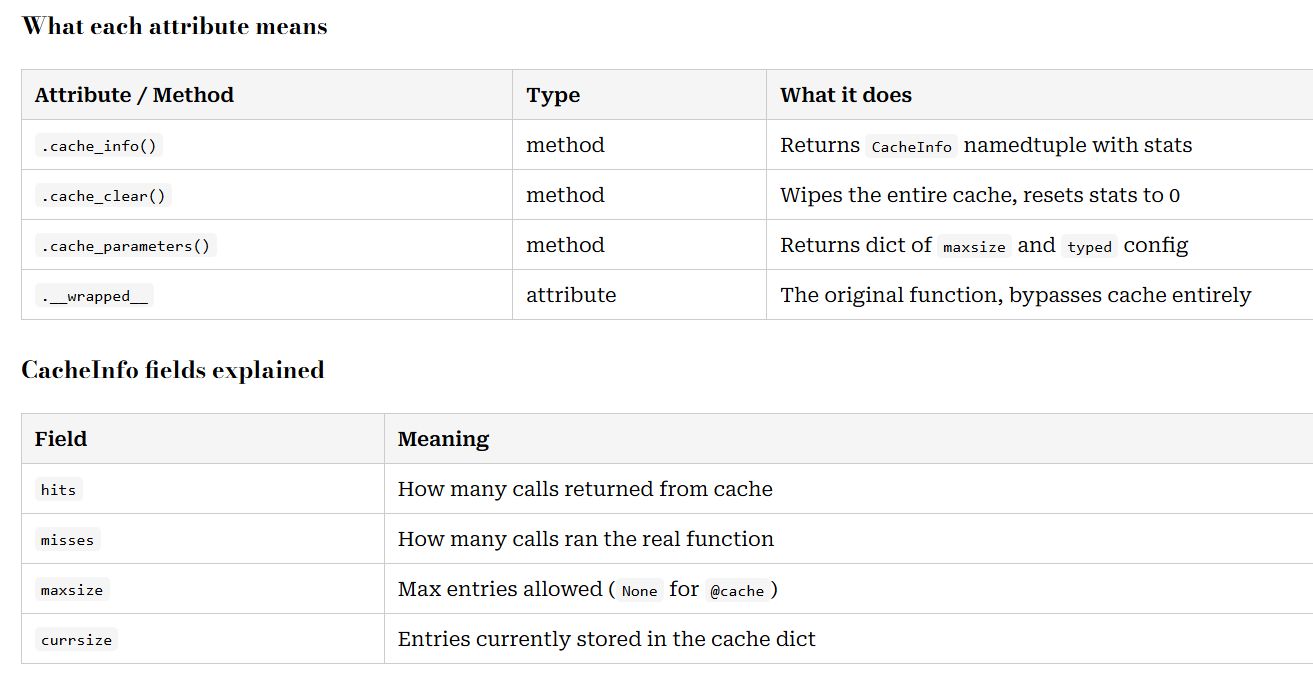

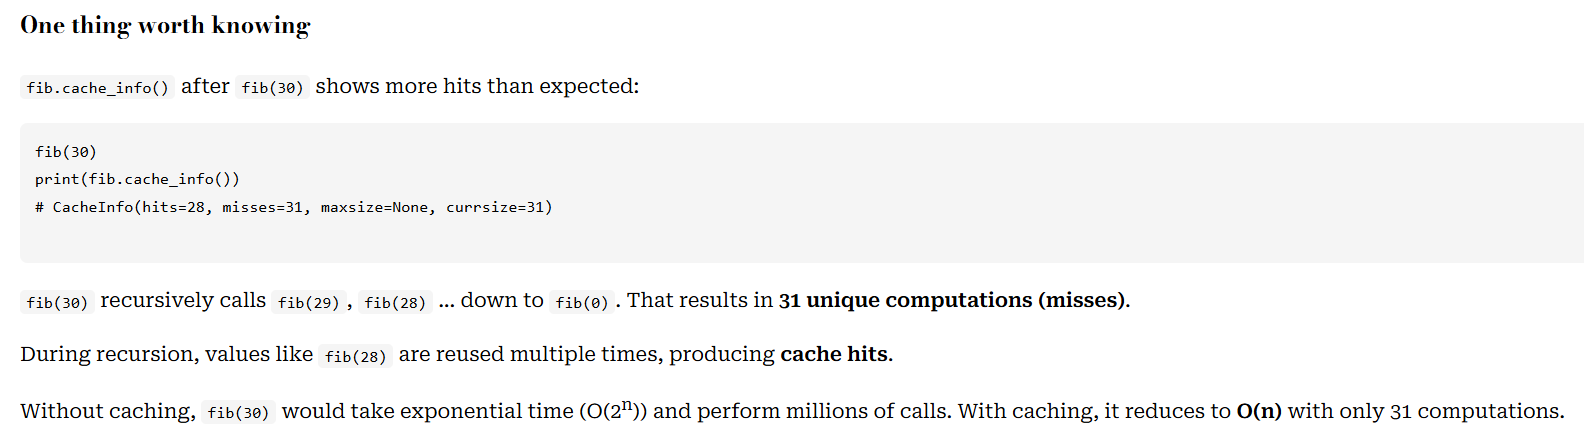

In [7]:
# ── cell 1: install ────────────────────────────────────────────────────────
# run once, then restart kernel if needed
# !pip install cachetools

In [8]:
# ── cell 2: imports ────────────────────────────────────────────────────────
import time
import random
import threading
from cachetools import TTLCache, LRUCache, LFUCache, cached, cachedmethod

In [10]:
# ── cell 3: mock external services ────────────────────────────────────────
class MockMarketAPI:
    def get_price(self, symbol: str) -> float:
        print(f"  [API CALL] Fetching price for {symbol}...")
        time.sleep(0.3)                           # simulate network latency
        prices = {"AAPL": 189.5, "TSLA": 245.3, "NVDA": 875.2, "GOOG": 178.4}
        base = prices.get(symbol, 100.0)
        return round(base + random.uniform(-2, 2), 2)


class MockDB:
    def fetch_user(self, user_id: int) -> dict:
        print(f"  [DB QUERY] Fetching user {user_id}...")
        time.sleep(0.2)                           # simulate DB latency
        return {
            "id": user_id,
            "name": f"User_{user_id}",
            "email": f"user{user_id}@example.com",
            "role": random.choice(["admin", "viewer", "editor"]),
        }


market_api = MockMarketAPI()
db         = MockDB()


In [11]:
# ── cell 4: TTLCache + @cached decorator ──────────────────────────────────
# TTLCache = LRU eviction + automatic TTL expiry combined
ttl_cache = TTLCache(maxsize=256, ttl=10)         # 10-sec TTL for demo (600 = 10 min in prod)

@cached(cache=ttl_cache)
def get_stock_price(symbol: str) -> float:
    return market_api.get_price(symbol)


# ── call 1: miss ───────────────────────────────────────────────────────────
t0 = time.perf_counter()
price = get_stock_price("AAPL")
t1 = time.perf_counter()
print(f"AAPL price: ${price}  |  time: {(t1-t0)*1000:.1f}ms  ← MISS")

# ── call 2: hit ────────────────────────────────────────────────────────────
t0 = time.perf_counter()
price = get_stock_price("AAPL")
t1 = time.perf_counter()
print(f"AAPL price: ${price}  |  time: {(t1-t0)*1000:.1f}ms  ← HIT")

# ── call 3: different key — miss ──────────────────────────────────────────
t0 = time.perf_counter()
price = get_stock_price("NVDA")
t1 = time.perf_counter()
print(f"NVDA price: ${price}  |  time: {(t1-t0)*1000:.1f}ms  ← MISS")

# ── cache state ────────────────────────────────────────────────────────────
print(f"\nCache size   : {len(ttl_cache)} / {ttl_cache.maxsize}")
print(f"Cache keys   : {list(ttl_cache.keys())}")
print(f"Cache values : {list(ttl_cache.values())}")

  [API CALL] Fetching price for AAPL...
AAPL price: $189.81  |  time: 300.9ms  ← MISS
AAPL price: $189.81  |  time: 0.1ms  ← HIT
  [API CALL] Fetching price for NVDA...
NVDA price: $873.28  |  time: 300.8ms  ← MISS

Cache size   : 2 / 256
Cache keys   : [('AAPL',), ('NVDA',)]
Cache values : [189.81, 873.28]


In [12]:
# ── cell 5: watch TTL expiry live ─────────────────────────────────────────
print("Waiting 11 seconds for TTL to expire...\n")
time.sleep(11)

t0 = time.perf_counter()
price = get_stock_price("AAPL")
t1 = time.perf_counter()
print(f"AAPL price: ${price}  |  time: {(t1-t0)*1000:.1f}ms  ← MISS after TTL expiry")
print(f"Cache size after expiry: {len(ttl_cache)}")

Waiting 11 seconds for TTL to expire...

  [API CALL] Fetching price for AAPL...
AAPL price: $189.9  |  time: 301.7ms  ← MISS after TTL expiry
Cache size after expiry: 1


In [13]:
# ── cell 6: LRUCache + @cachedmethod on class ─────────────────────────────
class UserService:
    def __init__(self):
        self._cache = LRUCache(maxsize=5)         # tiny maxsize=5 to demo eviction
        self._lock  = threading.Lock()

    @cachedmethod(lambda self: self._cache, lock=lambda self: self._lock)
    def get_user(self, user_id: int) -> dict:
        return db.fetch_user(user_id)

    def invalidate(self, user_id: int) -> None:
        """Call this after updating user in DB."""
        with self._lock:
            self._cache.pop(user_id, None)
        print(f"  [INVALIDATED] user:{user_id} removed from cache")

    def cache_state(self) -> None:
        print(f"  Cache ({len(self._cache)}/{self._cache.maxsize}): {dict(self._cache)}")


svc = UserService()


# ── miss then hit ──────────────────────────────────────────────────────────
print("\n-- First fetch (miss) --")
u = svc.get_user(101)
print(f"Got: {u}")
svc.cache_state()

print("\n-- Second fetch (hit) --")
u = svc.get_user(101)
print(f"Got: {u}")
svc.cache_state()


-- First fetch (miss) --
  [DB QUERY] Fetching user 101...
Got: {'id': 101, 'name': 'User_101', 'email': 'user101@example.com', 'role': 'viewer'}
  Cache (1/5): {(101,): {'id': 101, 'name': 'User_101', 'email': 'user101@example.com', 'role': 'viewer'}}

-- Second fetch (hit) --
Got: {'id': 101, 'name': 'User_101', 'email': 'user101@example.com', 'role': 'viewer'}
  Cache (1/5): {(101,): {'id': 101, 'name': 'User_101', 'email': 'user101@example.com', 'role': 'viewer'}}


In [14]:
# ── cell 7: LRU eviction demo ─────────────────────────────────────────────

print("LRU eviction demo — maxsize=5")


# fill cache to maxsize
for uid in [101, 102, 103, 104, 105]:
    svc.get_user(uid)

print("\nCache full:")
svc.cache_state()

# access 101 to make it recently used
svc.get_user(101)
print("\nAfter accessing 101 (moves to MRU end):")
svc.cache_state()

# add one more — 102 is now LRU (101 was just accessed), so 102 gets evicted
print("\nFetching user 106 — triggers eviction of LRU entry:")
svc.get_user(106)
svc.cache_state()

LRU eviction demo — maxsize=5
  [DB QUERY] Fetching user 102...
  [DB QUERY] Fetching user 103...
  [DB QUERY] Fetching user 104...
  [DB QUERY] Fetching user 105...

Cache full:
  Cache (5/5): {(101,): {'id': 101, 'name': 'User_101', 'email': 'user101@example.com', 'role': 'viewer'}, (102,): {'id': 102, 'name': 'User_102', 'email': 'user102@example.com', 'role': 'viewer'}, (103,): {'id': 103, 'name': 'User_103', 'email': 'user103@example.com', 'role': 'editor'}, (104,): {'id': 104, 'name': 'User_104', 'email': 'user104@example.com', 'role': 'editor'}, (105,): {'id': 105, 'name': 'User_105', 'email': 'user105@example.com', 'role': 'admin'}}

After accessing 101 (moves to MRU end):
  Cache (5/5): {(101,): {'id': 101, 'name': 'User_101', 'email': 'user101@example.com', 'role': 'viewer'}, (102,): {'id': 102, 'name': 'User_102', 'email': 'user102@example.com', 'role': 'viewer'}, (103,): {'id': 103, 'name': 'User_103', 'email': 'user103@example.com', 'role': 'editor'}, (104,): {'id': 104, '

In [15]:
# ── cell 9: thread-safety demo ────────────────────────────────────────────
print("Thread-safety demo — 10 threads hitting same user")
svc3 = UserService()
results = []

def fetch_concurrent(uid):
    user = svc3.get_user(uid)
    results.append(user["id"])

threads = [threading.Thread(target=fetch_concurrent, args=(301,)) for _ in range(10)]

for t in threads:
    t.start()
for t in threads:
    t.join()

print(f"\nAll 10 threads returned user id: {set(results)}")
print(f"DB was called exactly once (one [DB QUERY] line above)")
print(f"Final cache state:")
svc3.cache_state()

Thread-safety demo — 10 threads hitting same user
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...
  [DB QUERY] Fetching user 301...

All 10 threads returned user id: {301}
DB was called exactly once (one [DB QUERY] line above)
Final cache state:
  Cache (1/5): {(301,): {'id': 301, 'name': 'User_301', 'email': 'user301@example.com', 'role': 'viewer'}}


In [16]:
# ── cell 10: LFUCache demo ────────────────────────────────────────────────
from cachetools import LFUCache

print("LFUCache demo — evicts least frequently used")

lfu = LFUCache(maxsize=3)

# ── populate ──────────────────────────────────────────────────────────────
lfu["AAPL"] = 189.5
lfu["TSLA"] = 245.3
lfu["NVDA"] = 875.2

# ── access AAPL and NVDA multiple times (increase frequency) ─────────────
for _ in range(5):
    _ = lfu["AAPL"]
for _ in range(3):
    _ = lfu["NVDA"]
# TSLA accessed 0 times after insert — least frequent

print(f"Before eviction: {list(lfu.keys())}")

# ── insert new key — TSLA (freq=0) gets evicted ───────────────────────────
lfu["GOOG"] = 178.4
print(f"After inserting GOOG: {list(lfu.keys())}")
print("TSLA evicted ✓  (it was least frequently accessed)")

LFUCache demo — evicts least frequently used
Before eviction: ['AAPL', 'TSLA', 'NVDA']
After inserting GOOG: ['AAPL', 'NVDA', 'GOOG']
TSLA evicted ✓  (it was least frequently accessed)
